In [1]:
import os
os.environ["JAX_MPS_ASYNC_DISPATCH"]="1"

In [2]:
import jax

from jax import numpy as jnp

import numpy as np

import scipy

from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import cm

import copy
import time
import datetime

In [3]:
key = jax.random.key(0)

dtype = jnp.float32

Platform 'mps' is experimental and not all JAX functionality may be correctly supported!
[jax-mps] JAX_MPS_ASYNC_DISPATCH is ON: async dispatch enabled — may be much faster, but experimental and may break. Unset it for safe synchronous execution.


In [4]:
T_R     = 4e5  # temperature of random agent (K)
T_C     = 2e6  # temperature of causal agent (K)
TAU     = 10.  # simulation time horizon (seconds)
EPSILON = .025 # timesteps (seconds)

NUM_ROLLOUTS = 100_000

SUBSAMPLING = True
NUM_SUBSAMPLES = 100

CHUNK_SIZE = 1000

In [5]:
M     = 1e-21                               # mass (kg)
L     = 400                                 # length (meters) 
Q_MIN = jnp.array([0. , 0.  ], dtype=dtype) # minimum box displacements
Q_MAX = jnp.array([L  , L/5.], dtype=dtype) # maximum box displacements

def step_p(p, f):
    p     = f * EPSILON
    p_max = M * jnp.abs(Q_MAX - Q_MIN) / EPSILON
    new_p = jnp.sign(p) * jnp.minimum(p_max, jnp.abs(p))
    return new_p

def step_q(q, p, new_p):
    new_q = q  +  .5 * EPSILON * (p + new_p) / M
    return new_q

def enforce_elastic_collisions(p, q):
    q  = jnp.maximum(q, 2 * Q_MIN - q)
    p *= jnp.sign(q - Q_MIN)
    q  = jnp.minimum(q, 2 * Q_MAX - q)
    p *= jnp.sign(Q_MAX - q)
    return p, q

def step_phase_space(p, q, f):
    new_p        = step_p(p, f)
    new_q        = step_q(q, p, new_p)
    new_p, new_q = enforce_elastic_collisions(new_p, new_q)
    return new_p, new_q

In [6]:
timesteps = int(TAU / EPSILON)

In [7]:
scale = np.sqrt(M * scipy.constants.Boltzmann * T_R) / EPSILON

In [8]:
def generate_fs(num_samples, key):
    # scale calculation formula from https://math.stackexchange.com/a/1426406
    noise  = jax.random.normal(key, shape=(num_samples, 2), dtype=dtype)
    noise *= scale
    return noise

def rollouts(p, q, key):
    """
    paths.shape = (timesteps, num_samples, q_dim)
    """
    ps = jnp.tile(p[None, :], (NUM_ROLLOUTS, 1))
    qs = jnp.tile(q[None, :], (NUM_ROLLOUTS, 1))

    paths = copy.deepcopy(qs[None, :])

    key, subkey = jax.random.split(key)
    fs          = generate_fs(NUM_ROLLOUTS, subkey)
    first_fs    = copy.deepcopy(fs)
    
    for i in range(timesteps):
        ps, qs      = step_phase_space(ps, qs, fs)
        paths       = jnp.append(paths, qs[None, :], axis=0)
        key, subkey = jax.random.split(key)
        fs          = generate_fs(NUM_ROLLOUTS, subkey)

    return paths, first_fs

In [9]:
def subsample(paths):
    # idea and code from Google Gemini to speed up KDE
    sub_indices = np.linspace( 0 ,
                               timesteps - 1 ,
                               NUM_SUBSAMPLES ,
                               dtype=np.int32 ) 
    sub_paths = paths[sub_indices, :, :]
    return sub_paths

In [10]:
# The following code is modified from 
# [1]: https://github.com/scipy/scipy/blob/main/scipy/stats/_kde.py
# [2]: https://github.com/scipy/scipy/blob/main/scipy/stats/_stats.pyx#L744
# [3]: code generated by Google Gemini Flash 3.6 to implement gaussian kde
# with diagonal bandwidth matrix (the idea to use a diagonal kernel was also
# suggested by Google Gemini Flash 3.6)
# 
# [1] has a copyright notice which I have reproduced below
# 
# -------------------------------------------------------------------------------
#
#  Define classes for (uni/multi)-variate kernel density estimation.
#
#  Currently, only Gaussian kernels are implemented.
#
#  Written by: Robert Kern
#
#  Date: 2004-08-09
#
#  Modified: 2005-02-10 by Robert Kern.
#              Contributed to SciPy
#            2005-10-07 by Robert Kern.
#              Some fixes to match the new scipy_core
#
#  Copyright 2004-2005 by Enthought, Inc.
#
# -------------------------------------------------------------------------------


def diag_gaussian_kde_logpdfs(dataset, subsampling=True, chunk_size=CHUNK_SIZE):
    d, m = dataset.shape
    
    std_per_dim = jnp.std(dataset, axis=1, keepdims=True)
    scotts_factor = jnp.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T.astype(dtype)

    log_pdfs = jnp.zeros(m)
    for j in range(0, m, chunk_size):
        arg = jnp.sum((dataset_ - dataset_[j : j+chunk_size][:, None]) ** 2., axis=-1)
        log_pdfs = log_pdfs.at[j : j+chunk_size].set(jax.scipy.special.logsumexp(-arg/2., axis=1))
    
    return log_pdfs

In [11]:
def log_vol_fracs(dataset):
    if SUBSAMPLING:
        dataset = subsample(dataset[1:])
    dataset = dataset.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)
    
    log_pdfs = diag_gaussian_kde_logpdfs(dataset)
    log_omega = -log_pdfs
    log_volume_fracs = log_omega - jax.scipy.special.logsumexp(log_omega)
    return log_volume_fracs

In [12]:
def entropic_force(p, q, key):
    paths, fs = rollouts(p, q, key)
    return jnp.mean( fs * log_vol_fracs(paths)[:, None] , axis=0 )

In [13]:
@jax.jit
def step_macrostate(p, q, key):
    key, subkey = jax.random.split(key)
    f_c  = 2. * T_C / T_R * entropic_force(p, q, subkey)
    p, q = step_phase_space(p, q, f_c)
    return p, q, key

In [14]:
p = jnp.array([0.   , 0.   ])
q = jnp.array([L/10., L/10.])

path = copy.deepcopy(q[None, :])

start_time = time.time()
for timestep in range(100):
    elapsed_time = time.time() - start_time
    print(timestep, datetime.timedelta(seconds=int(elapsed_time)), q)

    p, q, key = step_macrostate(p, q, key)
    path = jnp.append(path, q[None, :], axis=0)

0 0:00:00 [40. 40.]
1 0:00:02 [40.54373  39.800102]
2 0:00:03 [40.985073 39.43016 ]
3 0:00:05 [40.377552 38.81867 ]
4 0:00:06 [39.046505 38.868073]
5 0:00:07 [37.762154 38.526558]
6 0:00:08 [37.356243 37.43335 ]
7 0:00:09 [36.401016 38.190556]
8 0:00:11 [33.86417  39.044403]
9 0:00:12 [31.445202 41.19917 ]
10 0:00:13 [30.920748 43.21118 ]
11 0:00:14 [30.594723 43.076157]
12 0:00:15 [31.919477 42.675865]
13 0:00:17 [34.365437 42.752834]
14 0:00:18 [35.011543 44.928085]
15 0:00:19 [36.83288 46.78457]
16 0:00:20 [37.84752  46.463017]
17 0:00:21 [37.13267 45.89067]
18 0:00:23 [36.424458 45.481922]
19 0:00:24 [34.183693 44.011276]
20 0:00:25 [32.19474 42.63442]
21 0:00:26 [31.806932 41.250168]
22 0:00:27 [32.86233 39.1535 ]
23 0:00:29 [34.218525 37.321182]
24 0:00:30 [34.432095 36.42994 ]
25 0:00:31 [34.145042 36.71129 ]
26 0:00:32 [33.88723  37.183075]
27 0:00:34 [34.002903 36.75238 ]
28 0:00:35 [33.33145 36.69602]
29 0:00:36 [30.90364 38.99745]
30 0:00:37 [29.525679 41.097054]
31 0:00:38 

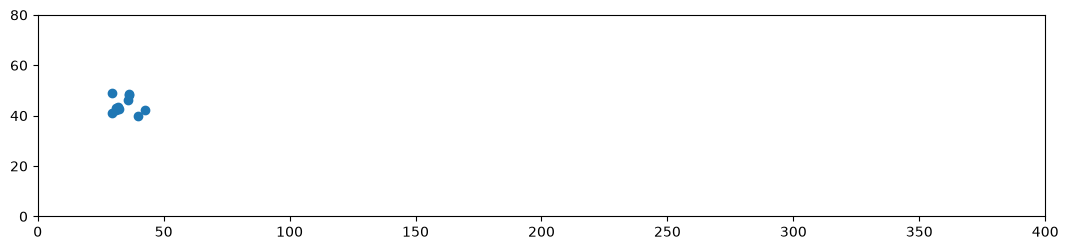

In [15]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.scatter(*path[::10].T)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect='equal')
plt.show()